In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from collections import Counter
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving brain_seg_all.zip to brain_seg_all.zip


In [ ]:
import zipfile
import os

zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset/brain_seg_all')

print("Unzipped!")

Unzipped!


In [ ]:
import os

base_path = "/content/dataset/brain_seg_all"

print(os.listdir(base_path))

['brain_dataset']


In [ ]:
print(os.listdir(base_path + "/brain_dataset"))

['train', 'val']


In [ ]:
print(os.listdir(base_path + "/brain_dataset/train"))

['Normal', 'Stroke']


In [ ]:
train_path = base_path + "/brain_dataset/train"
val_path = base_path + "/brain_dataset/val"

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------- TRANSFORMS --------------------
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# -------------------- DATA --------------------
train_dataset = datasets.ImageFolder(train_path, transform=train_transform)
val_dataset = datasets.ImageFolder(val_path, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Classes:", train_dataset.classes)

# -------------------- CLASS WEIGHTS --------------------
labels = [label for _, label in train_dataset]
counts = Counter(labels)
total = sum(counts.values())

weights = torch.tensor([total/counts[i] for i in range(len(counts))]).to(device)

# -------------------- MODEL --------------------
model = models.efficientnet_b0(weights="IMAGENET1K_V1")
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
model = model.to(device)

# Freeze all
# Freeze all
for param in model.parameters():
    param.requires_grad = False

# 🔥 Unfreeze MORE layers (key fix)
for param in model.features[2:].parameters():
    param.requires_grad = True

# Classifier
for param in model.classifier.parameters():
    param.requires_grad = True

# -------------------- LOSS --------------------
criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)

# -------------------- OPTIMIZER --------------------
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-4,
    weight_decay=1e-4
)

# -------------------- SCHEDULER --------------------
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.3)

# -------------------- TRAIN --------------------
num_epochs = 25
best_acc = 0

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # -------- VALIDATION --------
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total

    # scheduler step AFTER validation
    scheduler.step(acc)

    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), "best_model.pth")

    print(f"Epoch {epoch+1} | Loss: {train_loss:.4f} | Val Acc: {acc:.2f}%")

print("Best Accuracy:", best_acc)

Classes: ['Normal', 'Stroke']
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 174MB/s]


Epoch 1 | Loss: 39.4744 | Val Acc: 72.19%
Epoch 2 | Loss: 33.9754 | Val Acc: 75.67%
Epoch 3 | Loss: 29.6960 | Val Acc: 78.07%
Epoch 4 | Loss: 26.6606 | Val Acc: 78.07%
Epoch 5 | Loss: 22.0054 | Val Acc: 81.02%
Epoch 6 | Loss: 20.5492 | Val Acc: 83.42%
Epoch 7 | Loss: 19.3628 | Val Acc: 84.22%
Epoch 8 | Loss: 18.5377 | Val Acc: 83.69%
Epoch 9 | Loss: 17.9215 | Val Acc: 82.62%
Epoch 10 | Loss: 17.3260 | Val Acc: 83.42%
Epoch 11 | Loss: 16.5680 | Val Acc: 83.69%
Epoch 12 | Loss: 17.2829 | Val Acc: 85.56%
Epoch 13 | Loss: 16.4741 | Val Acc: 84.22%
Epoch 14 | Loss: 16.3937 | Val Acc: 83.96%
Epoch 15 | Loss: 16.6509 | Val Acc: 84.49%
Epoch 16 | Loss: 16.6371 | Val Acc: 85.03%
Epoch 17 | Loss: 16.6028 | Val Acc: 83.69%
Epoch 18 | Loss: 16.2922 | Val Acc: 83.69%
Epoch 19 | Loss: 16.3787 | Val Acc: 84.76%
Epoch 20 | Loss: 16.4646 | Val Acc: 85.03%
Epoch 21 | Loss: 16.8377 | Val Acc: 83.96%
Epoch 22 | Loss: 16.3555 | Val Acc: 83.96%
Epoch 23 | Loss: 16.7992 | Val Acc: 84.76%
Epoch 24 | Loss: 16.

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load EfficientNet
model = models.efficientnet_b0(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.to(device)
model.eval()

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()
img_path = list(uploaded.keys())[0]

print("Uploaded:", img_path)

Saving a60492e46b37a152fe2660a6090824a88f1d635fffc80836507b303efdb14280_gallery.jpeg to a60492e46b37a152fe2660a6090824a88f1d635fffc80836507b303efdb14280_gallery.jpeg
Uploaded: a60492e46b37a152fe2660a6090824a88f1d635fffc80836507b303efdb14280_gallery.jpeg


In [ ]:
from PIL import Image
from torchvision import transforms

image = Image.open(img_path).convert("RGB")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

img = transform(image).unsqueeze(0).to(device)

In [ ]:
import torch.nn.functional as F

class_names = ['normal', 'stroke']

with torch.no_grad():
    output = model(img)
    probs = F.softmax(output, dim=1)

# Probabilities
normal_prob = probs[0][0].item()
stroke_prob = probs[0][1].item()

# Prediction
_, pred = torch.max(output, 1)
confidence = probs[0][pred.item()].item()

# SMART DECISION LOGIC
if confidence < 0.65:
    prediction = "uncertain"
elif pred.item() == 1 and stroke_prob < 0.7:
    prediction = "normal"   # reduce false stroke
else:
    prediction = class_names[pred.item()]

In [ ]:
print("\nPrediction:", prediction.upper())
print(f"Confidence: {confidence*100:.2f}%")

print("\nClass Probabilities:")
print(f"Normal: {normal_prob*100:.2f}%")
print(f"Stroke: {stroke_prob*100:.2f}%")


Prediction: STROKE
Confidence: 79.54%

Class Probabilities:
Normal: 20.46%
Stroke: 79.54%


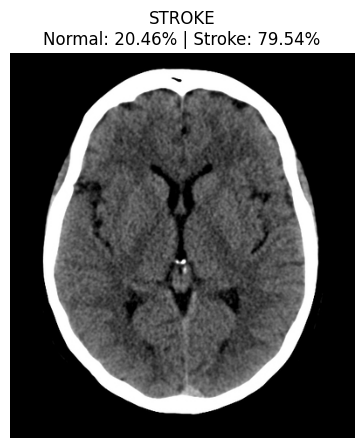

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.imshow(image)

plt.title(
    f"{prediction.upper()}\n"
    f"Normal: {normal_prob*100:.2f}% | Stroke: {stroke_prob*100:.2f}%"
)

plt.axis("off")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Convert lists to numpy (if needed)
y_true = all_labels
y_pred = all_preds
y_prob = all_probs

# Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)

# Print exactly like your screenshot
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("AUC-ROC:", auc)

Accuracy: 0.8556149732620321
Precision: 0.7972972972972973
Recall: 0.8309859154929577
F1 Score: 0.8137931034482758
AUC-ROC: 0.9328254006799417


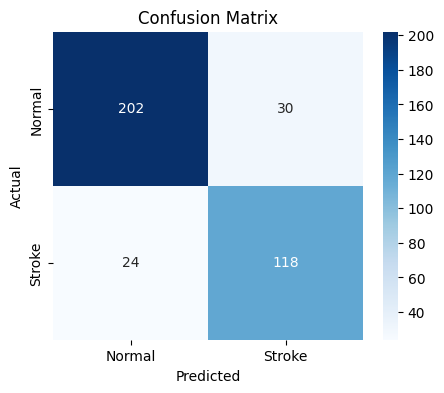

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Stroke'],
            yticklabels=['Normal', 'Stroke'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
!pip install gradio

In [ ]:
import gradio as gr
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms

# Transform (same as yours)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

class_names = ['Normal', 'Stroke']

def predict(image):
    image = image.convert("RGB")
    img = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img)
        probs = F.softmax(output, dim=1)

        normal_prob = probs[0][0].item()
        stroke_prob = probs[0][1].item()

        _, pred = torch.max(output, 1)
        confidence = probs[0][pred.item()].item()

        # Decision logic
        if confidence < 0.65:
            result = "⚠️ UNCERTAIN"
        elif pred.item() == 1 and stroke_prob < 0.7:
            result = "✅ NORMAL"
        else:
            result = "🧠 STROKE"

    return result, confidence, {"Normal": normal_prob, "Stroke": stroke_prob}

# Custom UI Design
with gr.Blocks(theme=gr.themes.Soft()) as demo:

    gr.Markdown("""
    # 🧠 Brain Stroke Detection System
    ### AI-powered CT Scan Analysis
    Upload a brain CT image to detect stroke presence.
    """)

    with gr.Row():
        with gr.Column():
            image_input = gr.Image(type="pil", label="📤 Upload CT Scan")
            btn = gr.Button("🔍 Analyze", variant="primary")

        with gr.Column():
            result_text = gr.Textbox(label="📊 Prediction Result")
            confidence_bar = gr.Slider(0, 1, label="Confidence", interactive=False)
            prob_output = gr.Label(label="Class Probabilities")

    btn.click(
        fn=predict,
        inputs=image_input,
        outputs=[result_text, confidence_bar, prob_output]
    )

    gr.Markdown("""
    ---
    ⚡ **Note:** This is an AI-assisted system and should support medical professionals.
    """)

demo.launch()

/tmp/ipykernel_1160/1264644640.py:42: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b9ca41d3d5f72d1284.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


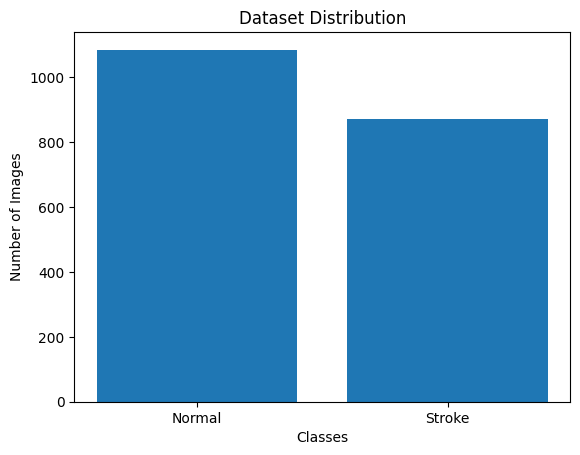

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

# Get labels
labels = [label for _, label in train_dataset]

# Count each class
class_counts = Counter(labels)

# Class names
class_names = train_dataset.classes
counts = [class_counts[i] for i in range(len(class_names))]

# Plot chart
plt.figure()
plt.bar(class_names, counts)
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Dataset Distribution")
plt.show()